# Family Model - Base Model

This notebook showcases our pipeline in action, for the "family" label classification task. This is our baseline model after the application of image cleaning, oversampling and resize, which were all handled in offline routines.

## Imports

The imports are composed of a mix of third-party libraries and several modules and constants that we have custom built to fit our needs.

In [13]:
# Standard Library
import os
from datetime import date

# Third-party libraries
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # type: ignore
from tensorflow.keras.metrics import AUC # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator, smart_resize  # type: ignore
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import model_from_json
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Internal modules
from deep.constants import BATCH_SIZE, INPUT_DIR, METADATA_DIR, METADATA_FILE, MODEL_IMAGE_SIZE, SEEDS, MODELS, MODEL_CONFIGS
from deep.modelling.metric_utils import get_fitted_model_metrics, plot_metrics, plot_confusion_matrix
from deep.modelling.pipiline_utils import split_data
from deep.preprocess.album_augmenter import compute_effective_class_weights
from deep.modelling.custom_loss import CategoricalFocalLoss
from deep.modelling.model_specifications import efficient_net_deep

## Loading Metadata and Splits

The foremost task is to obtain the metadata for our image files.

In [2]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum','is_animal'], inplace=True)

data

,rare_species_id,family,file_path
0,75fd91cb-2881-41cd-88e6-de451e8b60e2,unionidae,12853737_449393.jpg
1,28c508bc-63ff-4e60-9c8f-1934367e1528,geoemydidae,20969394_793083.jpg
2,00372441-588c-4af8-9665-29bee20822c0,cryptobranchidae,28895411_319982.jpg
3,29cc6040-6af2-49ee-86ec-ab7d89793828,turdidae,29658536_45510188.jpg
4,94004bff-3a33-4758-8125-bf72e6e57eab,indriidae,21252576_7250886.jpg
...,...,...,...
11978,1fa96ea5-32fa-4a25-b8d2-fa99f6e2cb89,leporidae,29734618_1011315.jpg
11979,628bf2b4-6ecc-4017-a8e6-4306849e0cfc,emydidae,29972861_1056842.jpg
11980,0ecfdec9-b1cd-4d43-96fc-2f8889ec1ad9,dasyatidae,30134195_52572074.jpg
11981,27fdb1e9-c5fb-459a-8b6a-6fb222b1c512,mustelidae,9474963_46559139.jpg


In [3]:
# Splitting the indices
train_df, val_df, test_df = split_data(data, 'family', seed=SEEDS[0], save_split=True)

In [4]:
upsampled = pd.read_csv(f'{METADATA_DIR}/family_upsample.csv')
upsampled

,rare_species_id,file_path,family
0,5a259dbb-e7b1-4485-9517-0fb0aa4a069d,14177753_45511531_accipitridae_rotate_30.jpg,accipitridae
1,5f151629-52f4-498f-8a7f-2a4a93dd9c32,30098505_205909_acipenseridae_rotate_30.jpg,acipenseridae
2,d54d7e19-5211-4bad-9cd8-55c3fab1a45c,28233665_205910_acipenseridae_rotate_30.jpg,acipenseridae
3,f362292e-1547-45b5-981c-08dbae0aa6a2,29619954_46561170_acipenseridae_rotate_30.jpg,acipenseridae
4,a1f99903-9a82-4873-b791-32f6b4353201,29537902_205910_acipenseridae_rotate_30.jpg,acipenseridae
...,...,...,...
41418,27ddf055-03fa-4f18-9c5c-8a0c72fc563b,20663362_205714_siluridae_flip_lr.jpg,siluridae
41419,595aa95e-78c3-49df-b421-e8bfd8181a06,28985463_205714_siluridae_bright_plus.jpg,siluridae
41420,e3ffb421-da44-4844-ad66-ea1e3814e88f,28985469_205714_siluridae_bright_plus.jpg,siluridae
41421,27ddf055-03fa-4f18-9c5c-8a0c72fc563b,20663362_205714_siluridae_bright_plus.jpg,siluridae


Per our framework, the oversamples that we created before and stored can be accessed by a common key with the main metadata.csv, and simply concatenated.

In [5]:
# Slice upsample with the selected indices 
aux_df = upsampled[upsampled['rare_species_id'].isin(train_df['rare_species_id'])]

# Update the metadata with the selected upsample indices
train_df = pd.concat([train_df,aux_df], ignore_index=True, axis=0)

# Looks good
train_df

,rare_species_id,family,file_path
0,002cf717-3a67-42c8-b855-cf8b2c4d6bd7,syngnathidae,2718903_46567771.jpg
1,26500c41-df95-4239-8e3e-b891c3d05458,iguanidae,29033055_963751.jpg
2,a35643c2-38cf-4712-a900-052d2528d713,pardalotidae,21055048_45518587.jpg
3,160213c1-306b-4be4-9c55-244fb0556e35,hylobatidae,28417389_326451.jpg
4,726e1436-5185-40cc-9e2a-38cf24791c9c,faviidae,28312775_45276847.jpg
...,...,...,...
36301,febd5527-ff11-4c12-8a21-a7416f9df934,siluridae,20663361_205714_siluridae_flip_lr.jpg
36302,27ddf055-03fa-4f18-9c5c-8a0c72fc563b,siluridae,20663362_205714_siluridae_flip_lr.jpg
36303,e3ffb421-da44-4844-ad66-ea1e3814e88f,siluridae,28985469_205714_siluridae_bright_plus.jpg
36304,27ddf055-03fa-4f18-9c5c-8a0c72fc563b,siluridae,20663362_205714_siluridae_bright_plus.jpg


## Image Generator

Image generator is setup with conservative values, as animal features like faces are not invariant under rotation. Test images were standardized according to the IMAGENET standard.

In [6]:
# Image Generator
train_datagen = ImageDataGenerator(
        rotation_range=90,
        shear_range=0.2,
        brightness_range=[0.8, 1.2],
        horizontal_flip=True,
        channel_shift_range=30.0,
        zoom_range=(0.8, 1.2),
        fill_mode='nearest',
        preprocessing_function=lambda image: smart_resize(image, size=MODEL_IMAGE_SIZE['efficientnetb4'])
    )

test_datagen = ImageDataGenerator(
        preprocessing_function=lambda image: smart_resize(image, size=MODEL_IMAGE_SIZE['efficientnetb4'])
    )

**Note: we were unable to debug the issue shown above with 232 images, however it was deemed to not be a source of data leakage, as far as we can diagnose it. .**

## Flow_from

Flow from dataframe along side each generator setup for each of the data splits.

In [7]:
# Train generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='family',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEEDS[0],
    shuffle=True
)

# Validation generator
val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='family',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Test generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=INPUT_DIR,
    x_col='file_path',
    y_col='family',
    target_size=MODEL_IMAGE_SIZE['efficientnetb4'],
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8148 validated image filenames belonging to 202 classes.
Found 1438 validated image filenames belonging to 202 classes.
Found 2397 validated image filenames belonging to 202 classes.


/home/nottoriousgg/miniconda3/envs/deep/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 28158 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


## Weights

Our loss function of choice was the MultiClass Focal Loss, a derivation of the Focal Loss.

In [8]:
# Map class weights from labels - indices using the generator
label_map = train_generator.class_indices
weights_str = compute_effective_class_weights(train_df, 'family')
weights_idx = {label_map[k]: v for k, v in weights_str.items()}

# Convert to list for alpha
alpha = [weights_idx[i] for i in range(len(weights_idx))]

# Instantiate focal loss
loss = CategoricalFocalLoss(gamma=5, alpha=alpha)

num_classes = train_df['family'].nunique()

## Model and Weights Loading

Our model is then instanced, and compiled, RMSprop was found to be a stable option.

In [10]:
# Load the model architecture from the JSON file
with open(os.path.join(MODEL_CONFIGS, 'model_base_architecture_2025-04-30.json'), 'r') as json_file:
    model_json = json_file.read()

model = model_from_json(model_json, custom_objects={'CategoricalFocalLoss': loss})

# Load the model weights
model.load_weights(os.path.join(MODELS, 'model_base_weights.weights.h5'))


2025-05-01 19:32:03.255495: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Evaluate Model

### Test metrics

Predict the test set via test generator, and then evaluate the results.

In [ ]:
# Predicting results on the test set
y_pred_proba = model.predict(test_generator, steps=len(test_generator), verbose=1)

# Obtaining our classification metadata
y_pred_classes = np.argmax(y_pred_proba, axis=1)
y_true_classes = test_generator.classes
class_indices = test_generator.class_indices
class_labels = list(class_indices.keys())

In [ ]:
# Accuracy
print("Accuracy:", accuracy_score(y_true_classes, y_pred_classes))

# F1 Scores
f1_macro = f1_score(y_true_classes, y_pred_classes, average='macro')
f1_weighted = f1_score(y_true_classes, y_pred_classes, average='weighted')
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Precision
precision_macro = precision_score(y_true_classes, y_pred_classes, average='macro')
precision_weighted = precision_score(y_true_classes, y_pred_classes, average='weighted')
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")

# Recall
recall_macro = recall_score(y_true_classes, y_pred_classes, average='macro')
recall_weighted = recall_score(y_true_classes, y_pred_classes, average='weighted')
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

ValueError: All arrays must be of the same length

/tmp/ipykernel_5977/2544134138.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Proportion Misclassified', y='Class', data=df_misclassified,


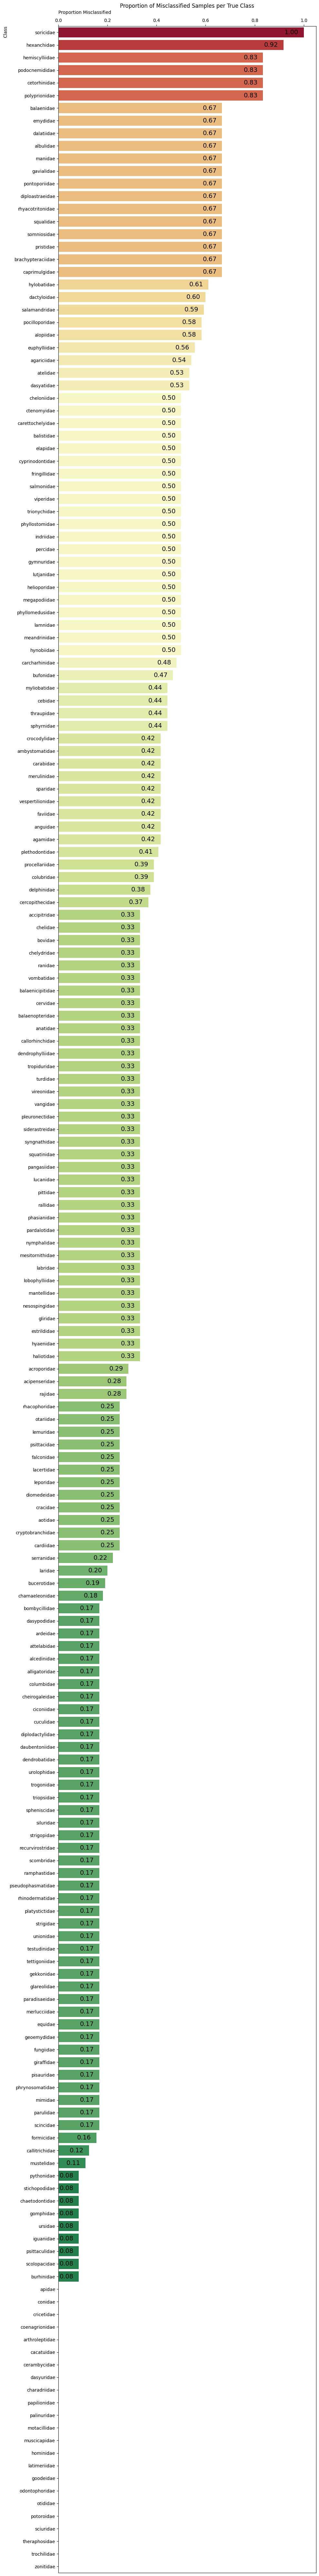

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

cm = confusion_matrix(y_true_classes, y_pred_classes)
labels = sorted(np.unique(np.concatenate((y_true_classes, y_pred_classes))))
total_per_class = cm.sum(axis=1)
misclassified = total_per_class - np.diag(cm)
proportion_misclassified = misclassified / total_per_class

# Create DataFrame without sorting immediately
df_misclassified = pd.DataFrame({
    'Class': labels,
    'Proportion Misclassified': proportion_misclassified
})

# Now sort the DataFrame based on 'Proportion Misclassified' after it's been created
df_misclassified = df_misclassified.sort_values(by='Proportion Misclassified', ascending=False)

# Normalize for color mapping
norm = Normalize(vmin=proportion_misclassified.min(), vmax=proportion_misclassified.max())
cmap = plt.cm.RdYlGn_r
colors = [cmap(norm(val)) for val in df_misclassified['Proportion Misclassified']]

plt.figure(figsize=(10, 80))
ax = sns.barplot(x='Proportion Misclassified', y='Class', data=df_misclassified,
                 palette=colors, order=df_misclassified['Class'], orient='h')

for index, value in enumerate(df_misclassified['Proportion Misclassified']):
    if value > 0:
        ax.text(value - 0.05, index, f'{value:.2f}', color='black', ha="center", va="center", fontsize=14)

plt.title('Proportion of Misclassified Samples per True Class')
plt.ylabel('Class', loc='top')

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel('Proportion Misclassified', labelpad=10, loc='left')
plt.yticks(ticks=np.arange(len(df_misclassified)), labels=df_misclassified['Class'].map(class_indices))

plt.tight_layout()
plt.show()


<Figure size 1000x8000 with 0 Axes>

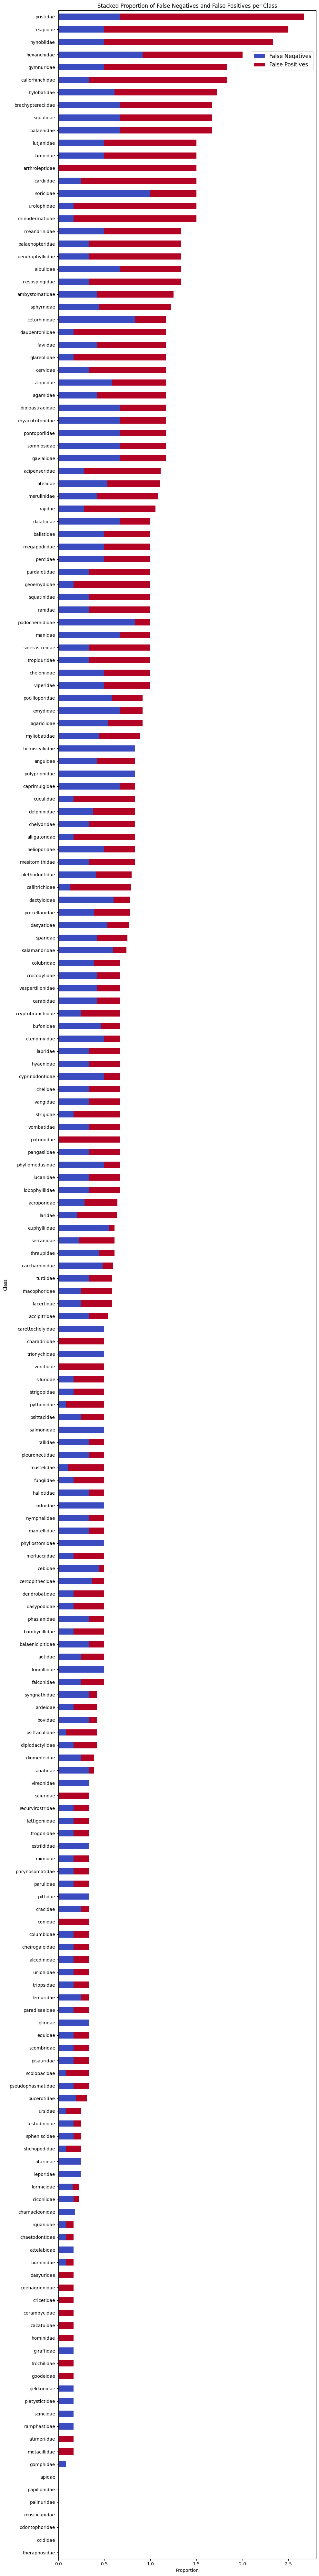

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_classes, y_pred_classes)
labels = sorted(np.unique(np.concatenate((y_true_classes, y_pred_classes))))
tp = np.diag(cm)
fn = cm.sum(axis=1) - tp
fp = cm.sum(axis=0) - tp
total = cm.sum(axis=1)

prop_fn = fn / total
prop_fp = fp / total

df_misclassified = pd.DataFrame({
    'Class': labels,
    'False Negatives': prop_fn,
    'False Positives': prop_fp,
    'Total Misclassified': prop_fn + prop_fp
})

df_misclassified = df_misclassified.sort_values(by='Total Misclassified', ascending=False)
df_plot = df_misclassified.set_index('Class')[['False Negatives', 'False Positives']]

plt.figure(figsize=(10, 80))
ax = df_plot.plot(kind='barh', stacked=True, colormap='coolwarm', figsize=(10, 80))

plt.xlabel('Proportion')
plt.title('Stacked Proportion of False Negatives and False Positives per Class')
plt.gca().invert_yaxis()

plt.yticks(ticks=np.arange(len(df_misclassified)), labels=df_misclassified['Class'].map(class_indices))
plt.legend(loc='upper right', bbox_to_anchor=(1, 0.985), fontsize=12) 
plt.tight_layout()
plt.show()


In [84]:
class_indices = {v: k for k, v in class_indices.items()}

In [85]:
df_misclassified['Class'].map(class_indices)



173         soricidae
94        hexanchidae
93     hemiscylliidae
145    podocnemididae
40       cetorhinidae
            ...      
148        potoroidae
166         sciuridae
185     theraphosidae
189       trochilidae
201         zonitidae
Name: Class, Length: 202, dtype: object

In [57]:
# Inspect the 'Class' column of df_misclassified and the class_indices keys
print(f"df_misclassified['Class'] values: {df_misclassified['Class'].unique()}")
print(f"class_indices keys: {list(class_indices.keys())}")

# Find the values in df_misclassified['Class'] that are not in class_indices
missing_classes = [class_name for class_name in df_misclassified['Class'] if class_name not in class_indices]
if missing_classes:
    print(f"Missing classes from class_indices: {missing_classes}")
else:
    print("All classes are found in class_indices.")


df_misclassified['Class'] values: [173  94  93 145  40 146  19  73  61   5 111  82 147  70 162 177 172 149
  24  31  97  60 163 144   8  76   4  16  62  46  57  35  21  72  59  80
 164 198 187 138 100 134  90 110  92 114 137 103 113  98  33  26 122  36
 186 176  55   9  32 116 174 197  78  11   3 142 150  50  66  38   0  45
  23  47 158 200  18  39  20  10  30  68 191 192 199 196 143 170 182 178
 129 109 140 156 135 132 124 117 101 108 112 123  87  75  96  91   2   1
 155 160 126 106 152  77 102 107  69  53  12  56  34 169 104  25  42  22
  63  14  17   6   7  51  44  48  58  71  65  67 194 190 188 175 171 181
 159 168 157 151 161 141 180 193 183 184  83  86 131 115  74  84  81  85
 139 136 118 133 165  79  29 121 154 179  41  88 195  99 153 167  27  13
  52  54  49  15  28  37  64  43 130 128 119 120  95 105  89 125 127 148
 166 185 189 201]
class_indices keys: [0, 1, 2]
Missing classes from class_indices: [173, 94, 93, 145, 40, 146, 19, 73, 61, 5, 111, 82, 147, 70, 162, 177, 172, 149